In [1]:
from psrqpy import QueryATNF
import numpy as np
import astropy.units as u

# Define Pulsar Arrays
EPTA = [
    "J1909-3744", "J1939+2134", "J1600-3053", "J1713+0747", "J1744-1134", "J1911+1347", "J1843-1113", "J1643-1224", "J0613-0200", "J1857+0943",
    "J2145-0750", "J1012+5307", "J2010-1323", "J1918-0642", "J1802-2124", "J1910+1256", "J1024-0719", "J1751-2857", "J1853+1303", "J0030+0451",
    "J1801-1417", "J1022+1001", "J1730-2304", "J0900-3144", "J0751+1807", "J1640+2224", "J2124-3358", "J1738+0333", "J1455-3330", "J1804-2717",
    "J2317+1439", "J0610-2100", "J0034-0534", "J1911-1114", "J0621+1002", "J0218+4232", "J2229+2643", "J2322+2057", "J1955+2908", "J2033+1734",
    "J1721-2457", "J2019+2425"
]
Epta_sigma_TOA = [
    0.26, 0.49, 0.55, 0.59, 1.21, 1.78, 2.48, 2.53, 2.57, 2.57,
    2.64, 2.73, 2.89, 3.18, 3.38, 3.39, 3.42, 3.52, 3.58, 3.79,
    3.81, 4.02, 4.17, 4.27, 4.33, 4.48, 5.57, 5.95, 7.07, 7.23,
    7.78, 8.14, 8.51, 8.82, 9.43, 10.51, 11.18, 12.47, 14.92, 18.24,
    24.28, 26.86, 6.200, 6.135  # not equal to size of EPTA array coz added sigma_RMS of J1207 and J0248 at the end
]

Own_array = ["J0248+4230", "J1207-5050"]
own_sigma_TOA = [6.200, 6.135]

NANOGrav = [
    "J0023+0923", "J0030+0451", "J0340+4130", "J0613-0200", "J0636+5128", "J0645+5158", "J0740+6620", "J0931-1902", "J1012+5307", "J1024-0719",
    "J1125+7819", "J1453+1902", "J1455-3330", "J1600-3053", "J1614-2230", "J1640+2224", "J1643-1224", "J1713+0747", "J1738+0333", "J1741+1351",
    "J1744-1134", "J1747-4036", "J1832-0836", "J1853+1303", "J1857+0943", "J1903+0327", "J1909-3744", "J1910+1256", "J1911+1347", "J1918-0642",
    "J1923+2515", "J1939+2134", "J1944+0907", "J1946+3417", "J1955+2908", "J2010-1323", "J2017+0603", "J2033+1734", "J2043+1711", "J2145-0750",
    "J2214+3000", "J2229+2643", "J2234+0611", "J2234+0944", "J2302+4442", "J2317+1439", "J2322+2057"
]
Nanograv_sigma_TOA = [
    0.285, 25.157, 0.446, 0.486, 0.64, 0.207, 0.132, 0.452, 0.999, 0.334,
    0.862, 0.606, 0.656, 0.245, 0.177, 0.177, 2.645, 0.101, 0.276, 0.156,
    0.832, 6.343, 0.187, 0.392, 1.757, 2.668, 0.334, 0.187, 0.118, 0.299,
    0.269, 2.277, 0.365, 0.468, 0.475, 0.244, 0.076, 0.561, 0.151, 1.467,
    0.402, 0.194, 0.061, 0.16, 0.716, 8.798, 0.235, 6.200, 6.135   # not equal to size of NANOGrav array coz added sigma_RMS of J1207 and J0248 at the end
]

InPTA = ["J1643-122", "J1713+074", "J1909-374", "J1939+2134", "J2145-0750"]
InPTA_sigma_TOA = [0.49, 0.06, 0.03, 0.04, 0.11, 6.200, 6.135]

# Combine all pulsar names
all_pulsars = list(set(EPTA + Own_array + NANOGrav + InPTA))

# Query ATNF for pulsar data
query = QueryATNF(psrs=all_pulsars, params=["JNAME", "RAJD", "DECJD", "GL", "GB", "DM", "P0", "P1", "VTRANS", "S400", "PB"])
pulsar_data = query.table

# Map sigma_TOA to pulsars
sigma_TOA_map = {}
for pulsar, sigma in zip(EPTA, Epta_sigma_TOA):
    sigma_TOA_map[pulsar] = sigma
for pulsar, sigma in zip(Own_array, own_sigma_TOA):
    sigma_TOA_map[pulsar] = sigma
for pulsar, sigma in zip(NANOGrav, Nanograv_sigma_TOA):
    sigma_TOA_map[pulsar] = sigma
for pulsar, sigma in zip(InPTA, InPTA_sigma_TOA):
    sigma_TOA_map[pulsar] = sigma

# Extract relevant data
for pulsar in all_pulsars:
    if pulsar in pulsar_data["JNAME"]:
        idx = list(pulsar_data["JNAME"]).index(pulsar)
        ra = pulsar_data["RAJD"][idx]
        dec = pulsar_data["DECJD"][idx]
        gl = pulsar_data["GL"][idx]
        gb = pulsar_data["GB"][idx]
        dm = pulsar_data["DM"][idx]
        p0 = pulsar_data["P0"][idx]
        p1 = pulsar_data["P1"][idx]
        pb = pulsar_data["PB"][idx]
        V_trans = pulsar_data["VTRANS"][idx]
        S400 = pulsar_data["S400"][idx]
        sigma_TOA = sigma_TOA_map.get(pulsar, None)

        #print(f"{pulsar}: RA={ra}, DEC={dec}, GL={gl}, GB={gb}, DM={dm}, P0={p0}, P1={p1}, Sigma_TOA={sigma_TOA} , V_trans= {V_trans}, S400= {S400}")
        print(f"Flux density (400 MHz):: Pulsar={pulsar}, {S400}")

#listing isolated pulsar
isolated_pulsars = []

for pulsar in all_pulsars:
    mask = pulsar_data["JNAME"] == pulsar  # returns boolean array
    if np.any(mask):
        PB = pulsar_data["PB"][mask][0]  # get the PB value for that pulsar
        if PB >= 0:  # only isolated pulsars
            isolated_pulsars.append(pulsar)

# Print the isolated pulsars
print("Pulsars with PB = 0 (isolated):")
for p in isolated_pulsars:
    print(p)

# Total count
print(f"\nTotal isolated pulsars: {len(isolated_pulsars)}")



# min, max and median values are::   S400,min​=1.3 mJy,S400,max​=240.0 mJy,S400,median​≈9.25 mJy



def get_fluxes(pulsar_list, pulsar_data):
    fluxes = []
    for pulsar in pulsar_list:
        if pulsar in pulsar_data["JNAME"]:
            idx = list(pulsar_data["JNAME"]).index(pulsar)
            S400 = pulsar_data["S400"][idx]
            try:
                val = float(S400)
                if np.isfinite(val):
                    fluxes.append(val)
            except Exception:
                continue
    return fluxes

# Collect fluxes


#epta_fluxes = get_fluxes(EPTA, pulsar_data)
#nanograv_fluxes = get_fluxes(NANOGrav, pulsar_data)

# Compute stats and counts
def describe_flux(fluxes, label):
    if not fluxes:
        print(f"No valid fluxes for {label}")
        return
    arr = np.array(fluxes)
    print(f"{label} S400 statistics (mJy):")
    print(f"  min   : {np.min(arr)}")
    print(f"  max   : {np.max(arr)}")
    print(f"  median: {np.median(arr)}")
    print(f"  count(<4 mJy): {np.sum(arr < 4)} out of {len(arr)} pulsars")
    print("")

#describe_flux(epta_fluxes, "EPTA")
#describe_flux(nanograv_fluxes, "NANOGrav")



/home/ssahoo/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Flux density (400 MHz):: Pulsar=J1804-2717, 15.0
Flux density (400 MHz):: Pulsar=J1751-2857, --
Flux density (400 MHz):: Pulsar=J2019+2425, --
Flux density (400 MHz):: Pulsar=J0740+6620, 32.5
Flux density (400 MHz):: Pulsar=J1946+3417, --
Flux density (400 MHz):: Pulsar=J0610-2100, --
Flux density (400 MHz):: Pulsar=J1832-0836, --
Flux density (400 MHz):: Pulsar=J2017+0603, --
Flux density (400 MHz):: Pulsar=J0931-1902, --
Flux density (400 MHz):: Pulsar=J0900-3144, --
Flux density (400 MHz):: Pulsar=J2234+0944, --
Flux density (400 MHz):: Pulsar=J1944+0907, 21.0
Flux density (400 MHz):: Pulsar=J0340+4130, 2.0
Flux density (400 MHz):: Pulsar=J1747-4036, --
Flux density (400 MHz):: Pulsar=J0636+5128, 1.8
Flux density (400 MHz):: Pulsar=J1857+0943, 20.0
Flux density (400 MHz):: Pulsar=J2214+3000, --
Flux density (400 MHz):: Pulsar=J1744-1134, 18.0
Flux density (400 MHz):: Pulsar=J1640+2224, 8.0
Flux density (400 MHz):: Pulsar=J1911-1114, 15.0
Flux density (400 MHz):: Pulsar=J2229+2643, 5

Processing EPTA: 42 pulsars
Filtered out pulsars (0):
Filtered pulsars (44):
Length of pulsar_names_filtered: 44
Length of sigma_TOA: 44

=== Highlighted Pulsars ===

Pulsar: J0248+4230
RAJD (Right Ascension): 42.12917916666666 deg
DECJD (Declination): 42.505691666666664 deg
GL (Galactic Longitude): 144.87726960741128 deg
GB (Galactic Latitude): -15.322393020003215 deg
DM (Dispersion Measure): 48.2634 pc cm⁻³
P0 (Spin Period): 0.002600834785631712 s
Elliptical Lattitude :: 25.036710449938923
Transverse Velocity :: nan

Pulsar: J1207-5050
RAJD (Right Ascension): 181.84334966666665 deg
DECJD (Declination): -50.84407777777778 deg
GL (Galactic Longitude): 295.86114929229416 deg
GB (Galactic Latitude): 11.4217184250559 deg
DM (Dispersion Measure): 50.64 pc cm⁻³
P0 (Spin Period): 0.004842757322802952 s
Elliptical Lattitude :: -44.69753990132321
Transverse Velocity :: 42.29148118355842
Transvelocity are :: [  9.6083707   77.49777397  97.4840698           nan 123.8180556
  47.35454007  22.1033

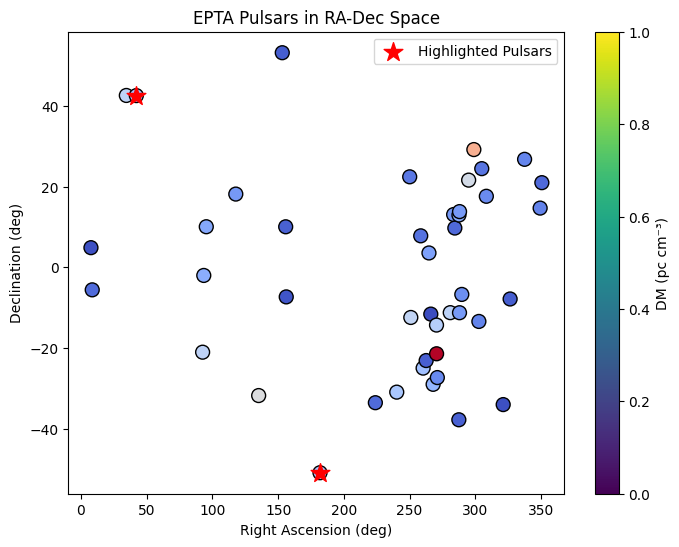

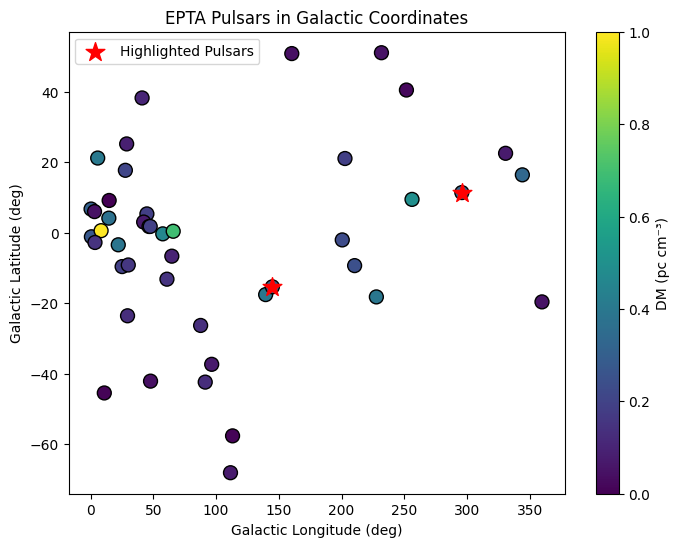

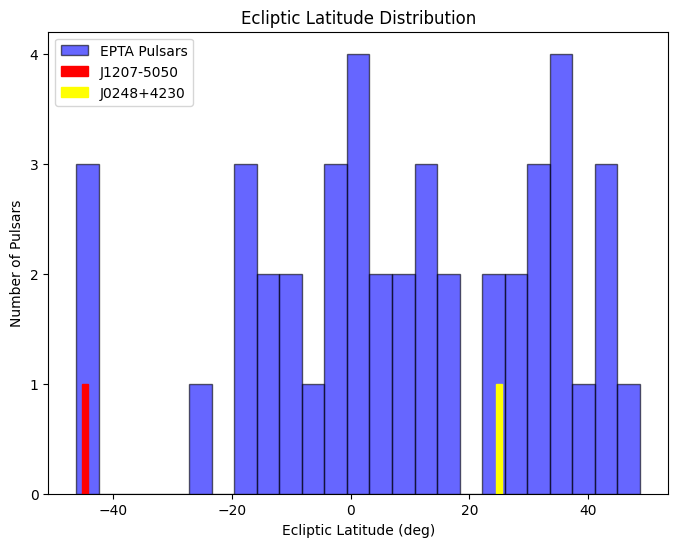

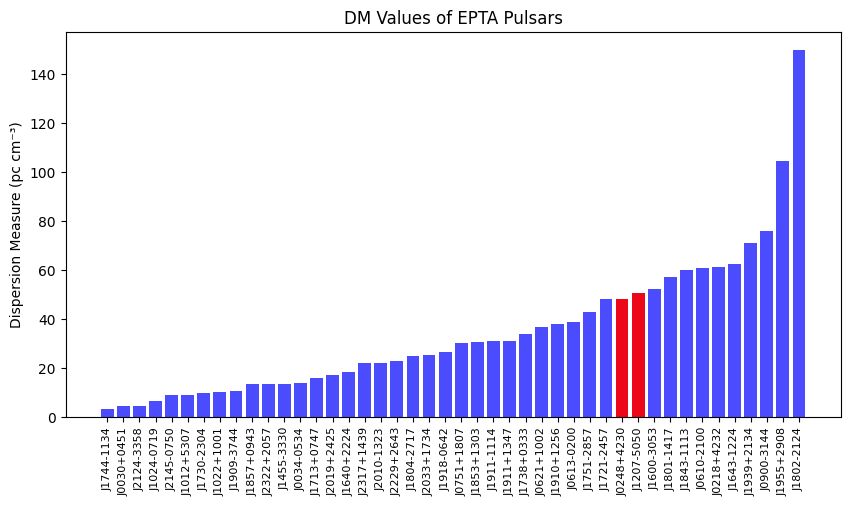

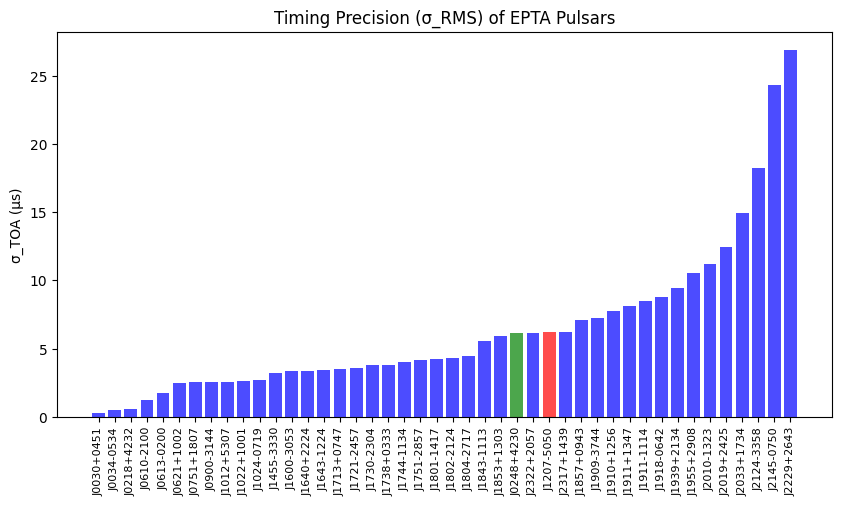

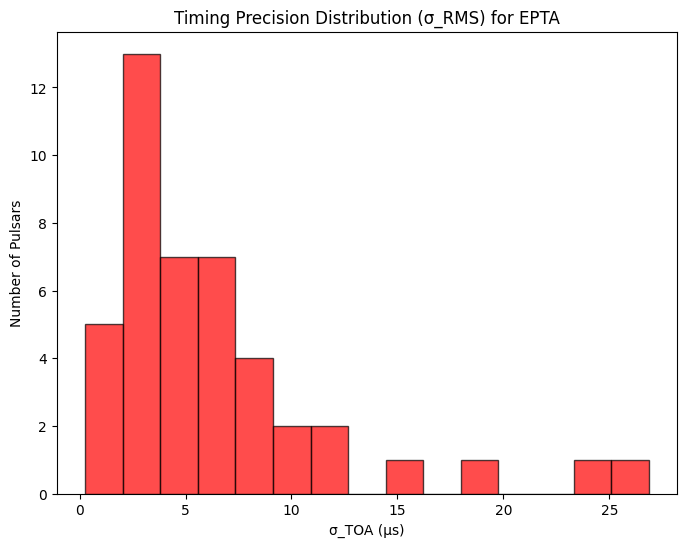

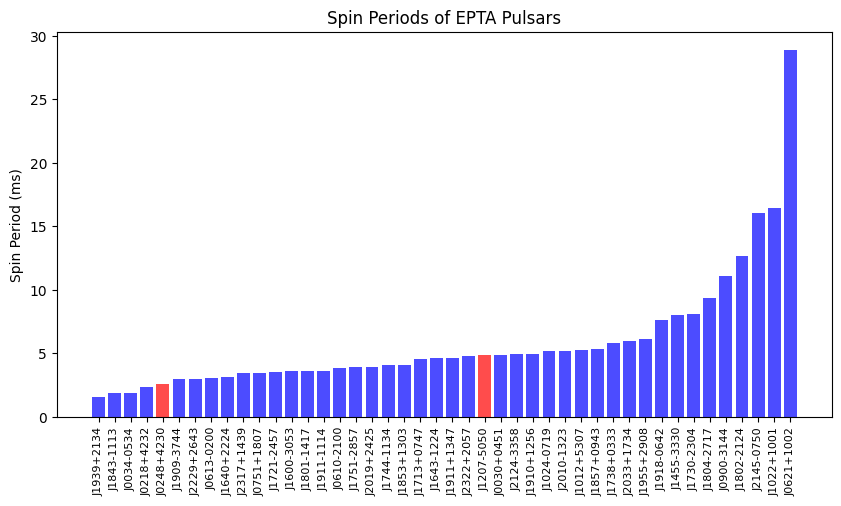

max DM:: 149.5902 and min_DM:: 3.13849


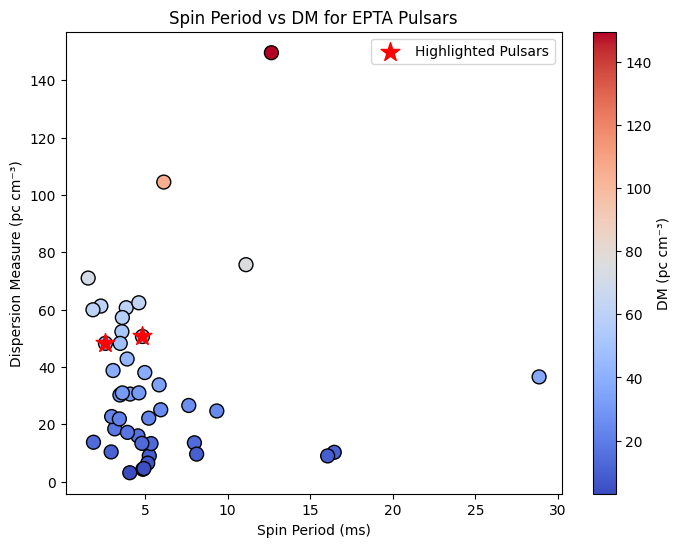

max DM:: 149.5902 and min_DM:: 3.13849


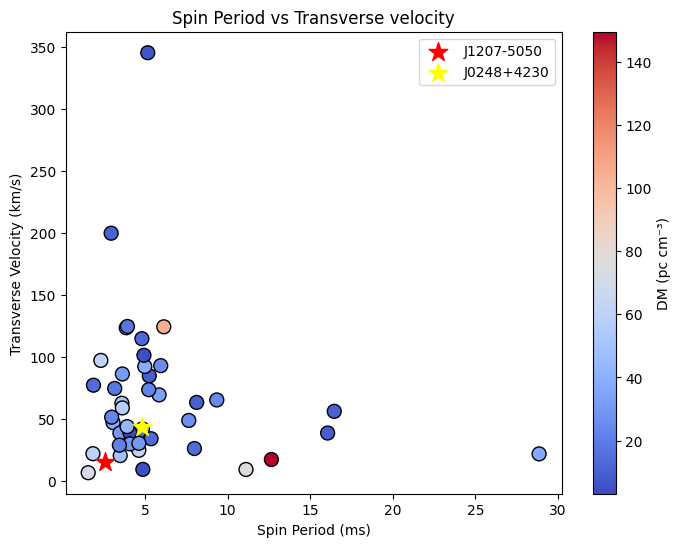

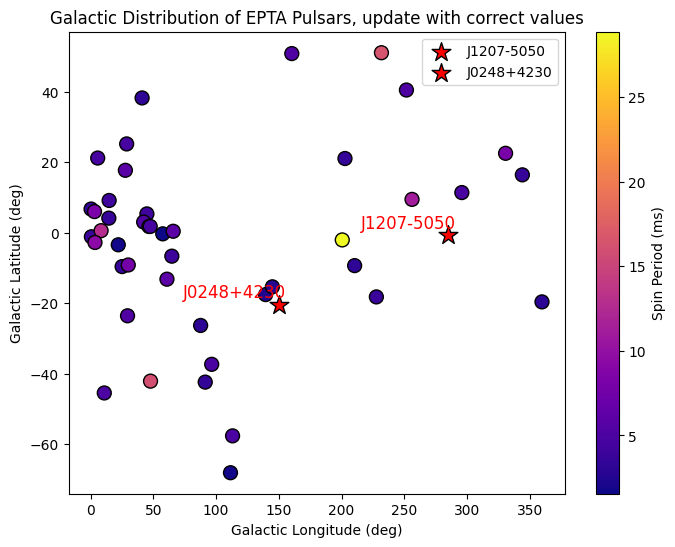

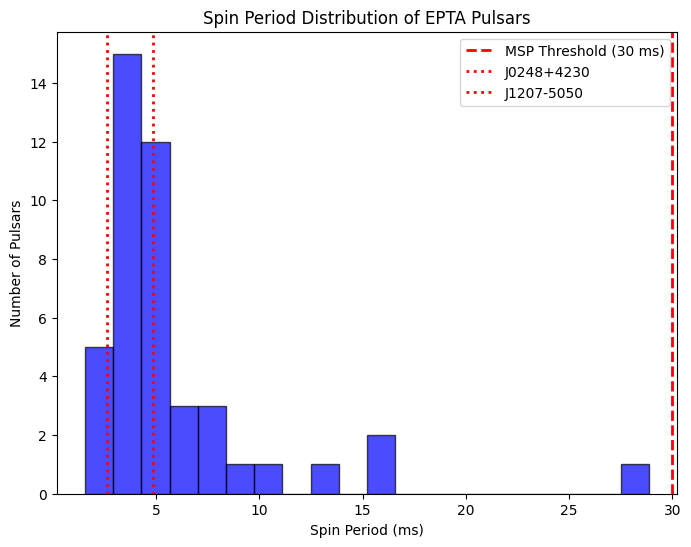

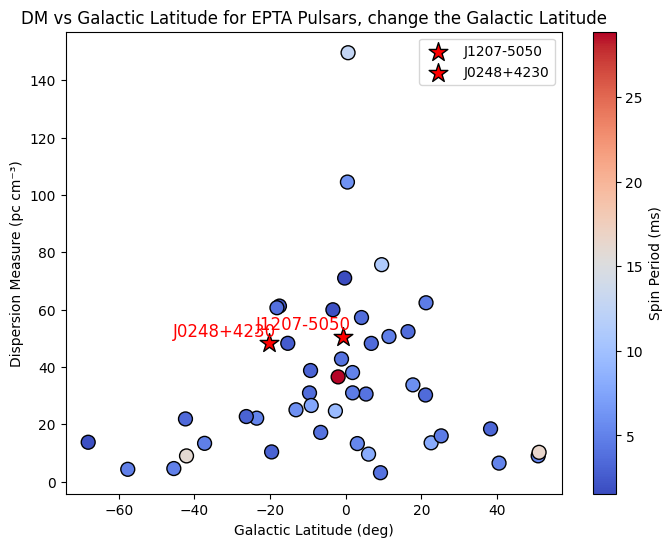

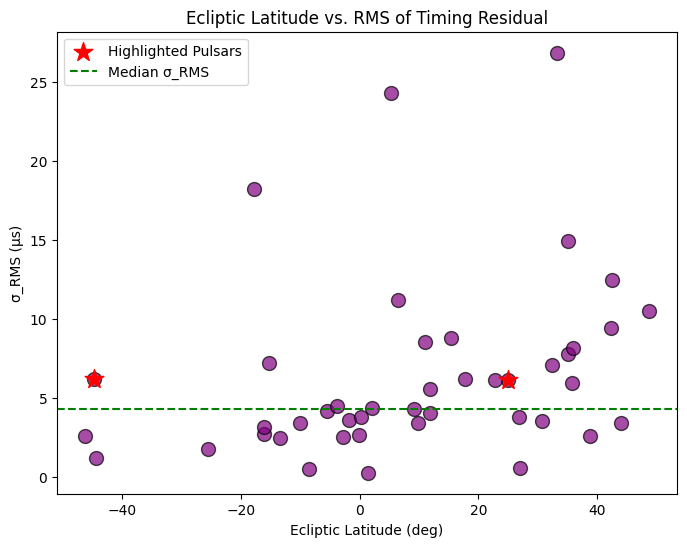

Processing NANOGrav: 47 pulsars
Filtered out pulsars (0):
Filtered pulsars (49):
Length of pulsar_names_filtered: 49
Length of sigma_TOA: 49

=== Highlighted Pulsars ===

Pulsar: J0248+4230
RAJD (Right Ascension): 42.12917916666666 deg
DECJD (Declination): 42.505691666666664 deg
GL (Galactic Longitude): 144.87726960741128 deg
GB (Galactic Latitude): -15.322393020003215 deg
DM (Dispersion Measure): 48.2634 pc cm⁻³
P0 (Spin Period): 0.002600834785631712 s
Elliptical Lattitude :: 25.036710449938923
Transverse Velocity :: nan

Pulsar: J1207-5050
RAJD (Right Ascension): 181.84334966666665 deg
DECJD (Declination): -50.84407777777778 deg
GL (Galactic Longitude): 295.86114929229416 deg
GB (Galactic Latitude): 11.4217184250559 deg
DM (Dispersion Measure): 50.64 pc cm⁻³
P0 (Spin Period): 0.004842757322802952 s
Elliptical Lattitude :: -44.69753990132321
Transverse Velocity :: 42.29148118355842
Transvelocity are :: [119.62374382   9.6083707           nan  25.63601306  47.35454007
  12.28583902  44

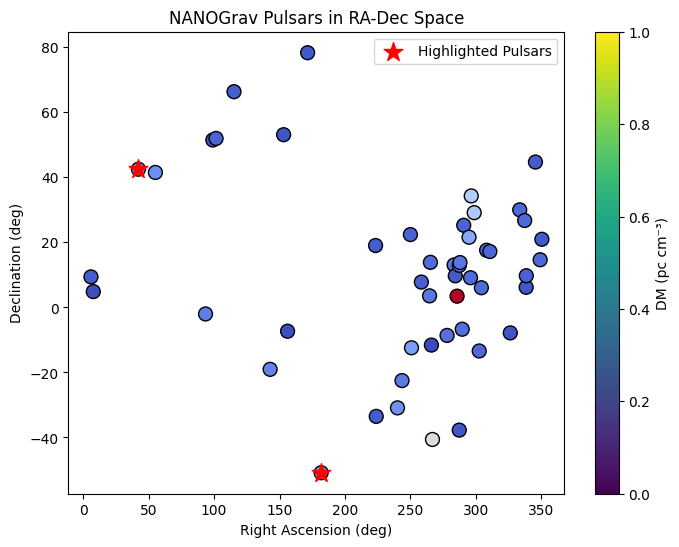

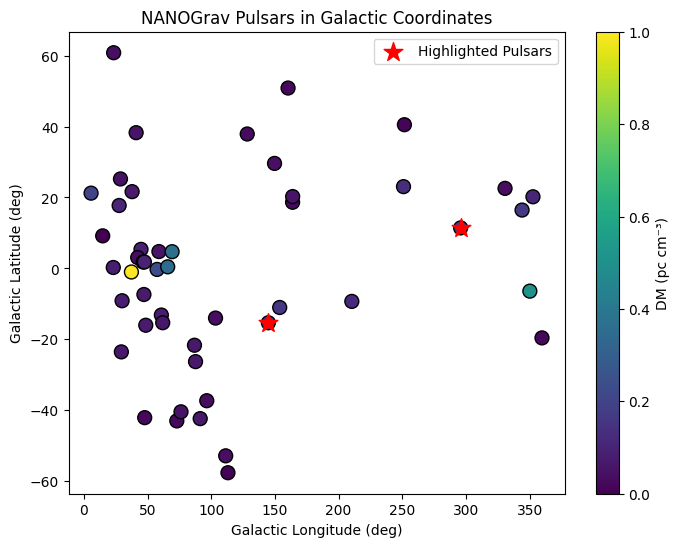

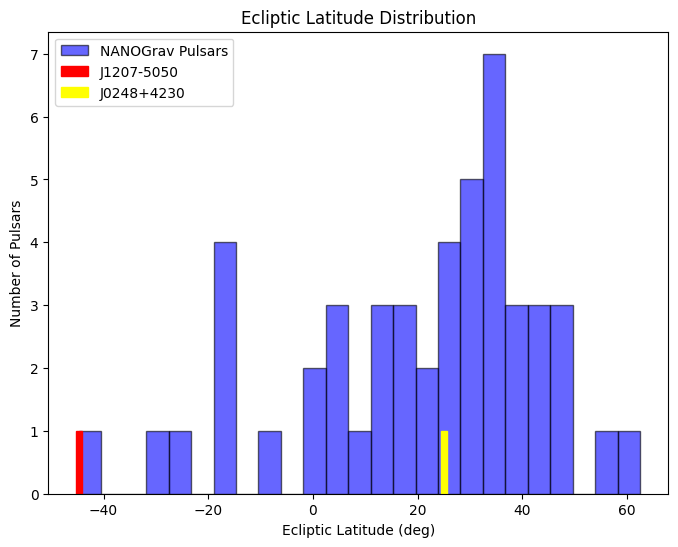

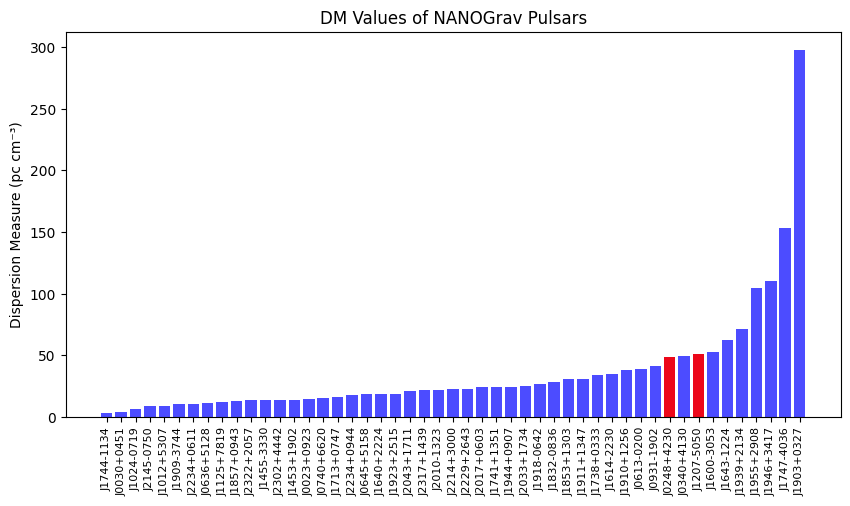

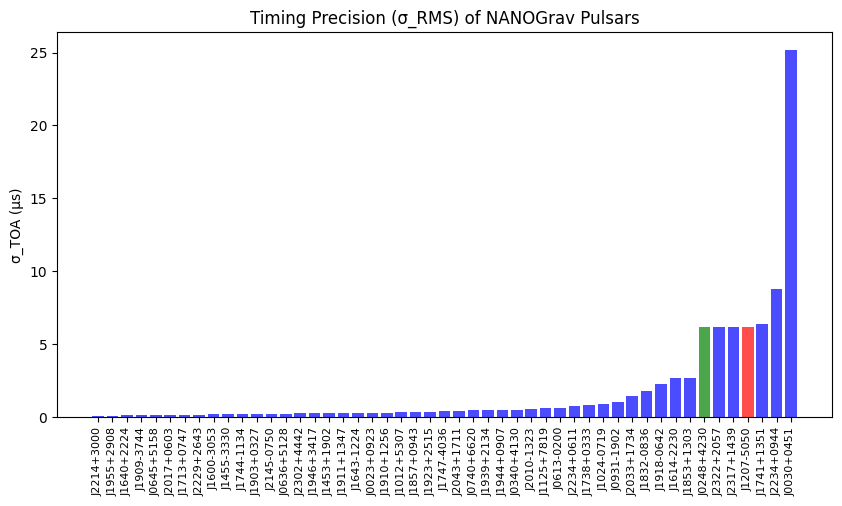

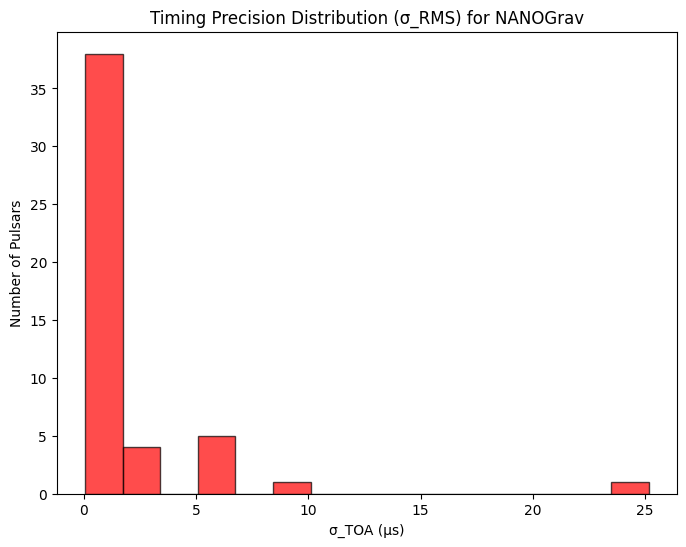

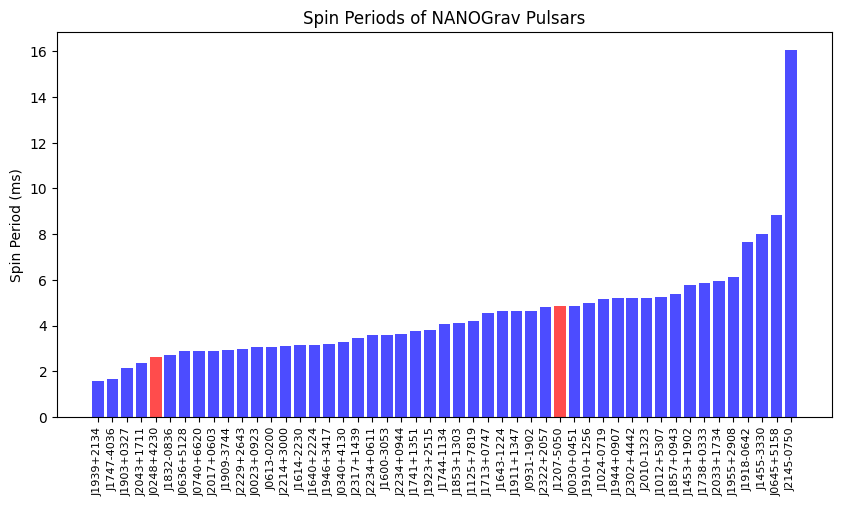

max DM:: 297.5245 and min_DM:: 3.13849


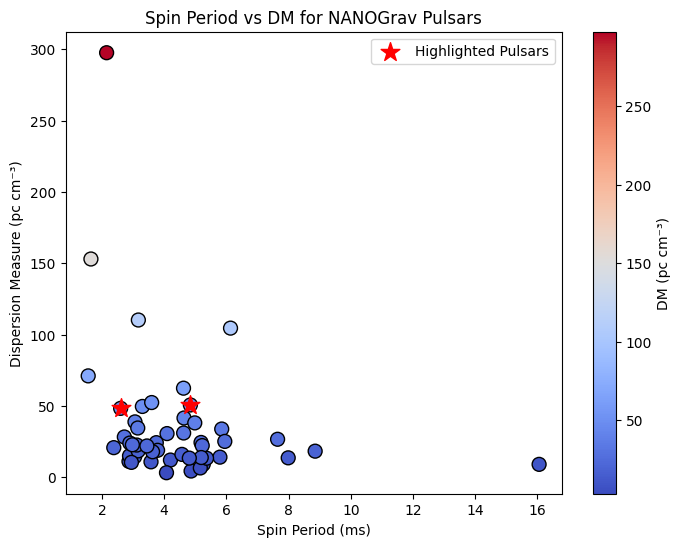

max DM:: 297.5245 and min_DM:: 3.13849


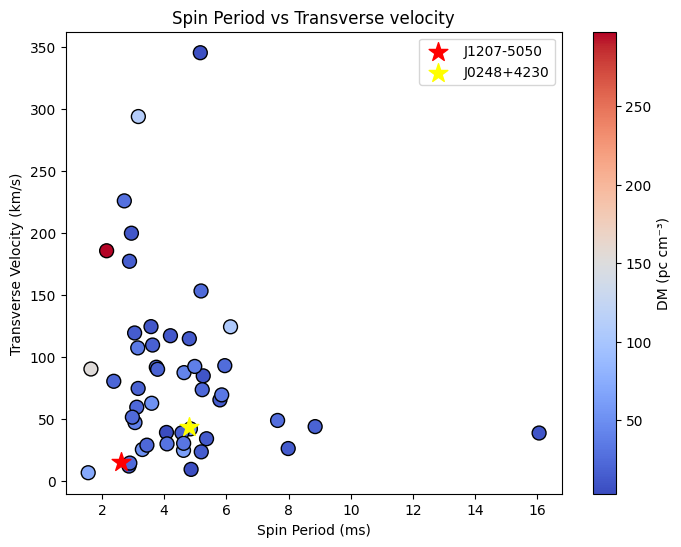

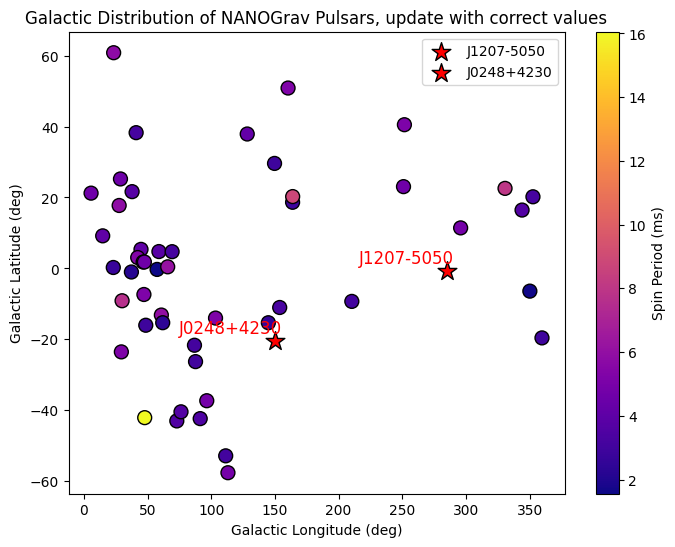

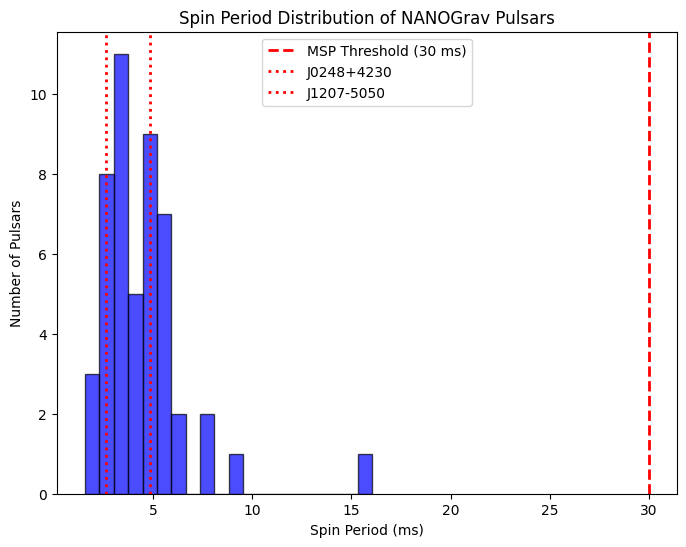

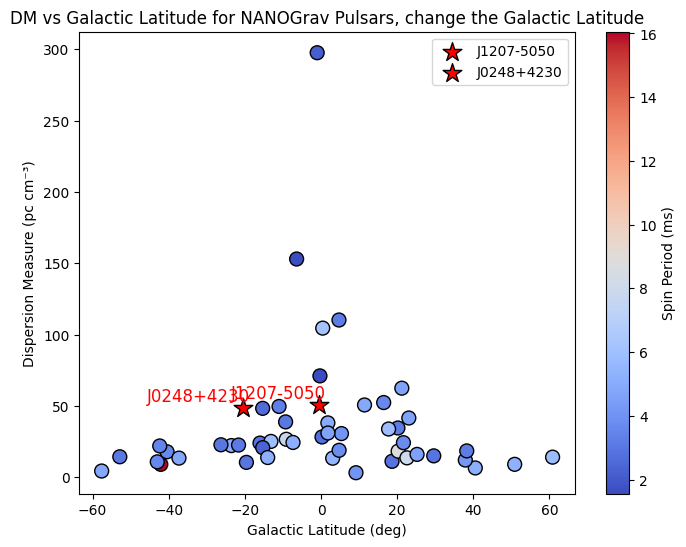

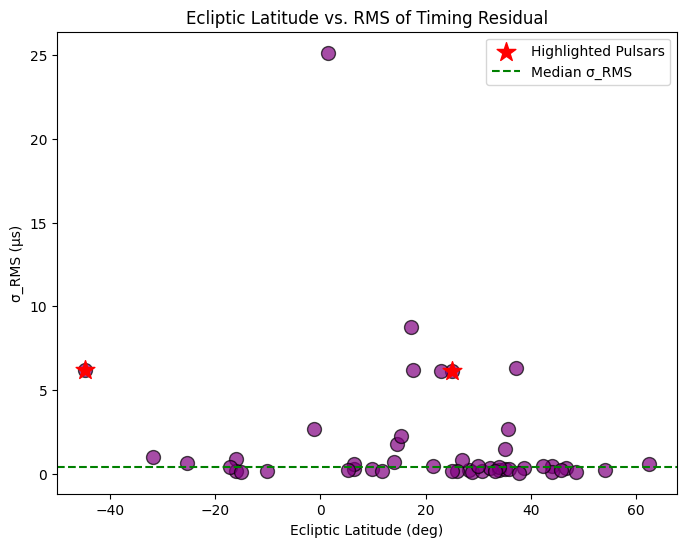

In [2]:
from psrqpy import QueryATNF
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.ticker as ticker





#all_ptas = {"EPTA": EPTA, "NANOGrav": NANOGrav, "InPTA": InPTA}
#all_TOAs = {"EPTA RMS": Epta_sigma_TOA, "NANOGrav RMS": Nanograv_sigma_TOA, "InPTA RMS": InPTA_sigma_TOA}

all_ptas = {"EPTA": EPTA, "NANOGrav": NANOGrav}
all_TOAs = {"EPTA RMS": Epta_sigma_TOA, "NANOGrav RMS": Nanograv_sigma_TOA}

highlight_pulsars = ["J1207-5050", "J0248+4230"]

def query_and_plot(pta_name, pulsar_list, sigma_TOA):
    query_params = ["JNAME", "RAJD", "DECJD", "GL", "GB", "DM", "P0", "VTRANS"]
    query = QueryATNF(params=query_params, psrs=pulsar_list + highlight_pulsars)
    pulsar_data = query.table
    
    valid_indices = ~np.isnan(pulsar_data["RAJD"]) & ~np.isnan(pulsar_data["DECJD"])
    pulsar_data = pulsar_data[valid_indices]
    
    ra_deg = np.array(pulsar_data["RAJD"], dtype=float)
    dec_deg = np.array(pulsar_data["DECJD"], dtype=float)
    gl = pulsar_data["GL"]
    gb = pulsar_data["GB"]
    dm_values = np.array(pulsar_data["DM"], dtype=float)
    p0_values = np.array(pulsar_data["P0"], dtype=float)
    V_trans = np.array(pulsar_data["VTRANS"], dtype=float)
    pulsar_names_filtered = pulsar_data["JNAME"]
    
    


    # Find filtered out pulsars
    filtered_out_pulsars = set(pulsar_list) - set(pulsar_names_filtered)

    print(f"Filtered out pulsars ({len(filtered_out_pulsars)}):")
    #for psr in sorted(filtered_out_pulsars):
    #    print(psr)
    print(f"Filtered pulsars ({len(pulsar_names_filtered)}):")
    #for psr1 in sorted(pulsar_names_filtered):
    #    print(psr1)
    print(f"Length of pulsar_names_filtered: {len(pulsar_names_filtered)}")
    print(f"Length of sigma_TOA: {len(sigma_TOA)}")

    
    coords = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    ecliptic_coords = coords.barycentrictrueecliptic
    ecliptic_lat = ecliptic_coords.lat.deg
    
    highlight_indices = [i for i, name in enumerate(pulsar_names_filtered) if name in highlight_pulsars]
    

    # Print values for highlighted pulsars
    print("\n=== Highlighted Pulsars ===")
    for idx in highlight_indices:
        print(f"\nPulsar: {pulsar_names_filtered[idx]}")
        print(f"RAJD (Right Ascension): {ra_deg[idx]} deg")
        print(f"DECJD (Declination): {dec_deg[idx]} deg")
        print(f"GL (Galactic Longitude): {gl[idx]} deg")
        print(f"GB (Galactic Latitude): {gb[idx]} deg")
        print(f"DM (Dispersion Measure): {dm_values[idx]} pc cm⁻³")
        print(f"P0 (Spin Period): {p0_values[idx]} s")
        print(f"Elliptical Lattitude :: {ecliptic_lat[idx]}")
        print(f"Transverse Velocity :: {V_trans[idx]}")

    #return pulsar_data  # Returning the full pulsar data if needed for further analysis
    print(f"Transvelocity are :: {V_trans}")



    # RA & Dec space plot
    plt.figure(figsize=(8, 6))
    plt.scatter(ra_deg, dec_deg, c=dm_values, cmap="coolwarm", edgecolors="k", s=100)
    plt.scatter(ra_deg[highlight_indices], dec_deg[highlight_indices], color='red', marker='*', s=200, label='Highlighted Pulsars')
    plt.colorbar(label="DM (pc cm⁻³)")
    plt.xlabel("Right Ascension (deg)")
    plt.ylabel("Declination (deg)")
    plt.title(f"{pta_name} Pulsars in RA-Dec Space")
    plt.legend()
    #plt.grid()
    plt.show()
    
    plt.figure(figsize=(8, 6))
    plt.scatter(gl, gb, c=dm_values, cmap="viridis", edgecolors="k", s=100)
    plt.scatter(gl[highlight_indices], gb[highlight_indices], color='red', marker='*', s=200, label='Highlighted Pulsars')
    plt.colorbar(label="DM (pc cm⁻³)")
    plt.xlabel("Galactic Longitude (deg)")
    plt.ylabel("Galactic Latitude (deg)")
    plt.title(f"{pta_name} Pulsars in Galactic Coordinates")
    plt.legend()
    #plt.grid()
    plt.show()




    # Find the index of the highlighted pulsars
    idx1 = np.where(pulsar_names_filtered == "J1207-5050")[0][0]
    idx2 = np.where(pulsar_names_filtered == "J0248+4230")[0][0]
    
    # Plot main histogram for all pulsars
    plt.figure(figsize=(8, 6))
    plt.hist(ecliptic_lat, bins=25, color='blue', edgecolor="black", alpha=0.6, label=f'{pta_name} Pulsars')
    # Overlay individual highlighted pulsars
    plt.hist([ecliptic_lat[idx1]], bins=1, color='red', edgecolor="red", alpha=1.0, label='J1207-5050')
    plt.hist([ecliptic_lat[idx2]], bins=1, color='yellow', edgecolor="yellow", alpha=1.0, label='J0248+4230')
    
    
    # Labels & legend
    plt.xlabel("Ecliptic Latitude (deg)")
    plt.ylabel("Number of Pulsars")
    plt.title(f"Ecliptic Latitude Distribution")
    # ✅ Set y-axis to use only integer values
    ax = plt.gca()
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.legend()
    plt.show()
    



    sorted_indices = np.argsort(dm_values)
    sorted_pulsar_names = np.array(pulsar_names_filtered)[sorted_indices]
    sorted_dm_values = dm_values[sorted_indices]

    plt.figure(figsize=(10, 5))
    plt.bar(sorted_pulsar_names, sorted_dm_values, color="blue", alpha=0.7)
    for idx in highlight_indices:
        plt.bar(pulsar_names_filtered[idx], dm_values[idx], color='red', alpha=0.9)
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Dispersion Measure (pc cm⁻³)")
    plt.title(f"DM Values of {pta_name} Pulsars")
    #plt.grid()
    plt.show()
    
    ####

    # Convert sigma_TOA to numpy array for easy manipulation
    sigma_TOA = np.array(sigma_TOA, dtype=float)

    # Update specific pulsar σ_TOA values
    for i, name in enumerate(pulsar_names_filtered):
        if name == "J1207-5050":
            sigma_TOA[i] = 6.20  # Set specific TOA value
        elif name == "J0248+4230":
            sigma_TOA[i] = 6.135  # Set specific TOA value

    # Sorting based on sigma_TOA
    sorted_indices_sigma = np.argsort(sigma_TOA)
    sorted_pulsar_names_sigma = np.array(pulsar_names_filtered)[sorted_indices_sigma]
    sorted_sigma_TOA = sigma_TOA[sorted_indices_sigma]

    # Assign colors, highlighting specific pulsars
    #highlighted_colors = ["red" if name in highlight_pulsars else "blue" for name in sorted_pulsar_names_sigma]
    highlighted_colors = ["red" if name == "J1207-5050" else "green" if name == "J0248+4230" else "blue" for name in sorted_pulsar_names_sigma]


    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(sorted_pulsar_names_sigma, sorted_sigma_TOA, color=highlighted_colors, alpha=0.7)
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("σ_TOA (µs)")
    plt.title(f"Timing Precision (σ_RMS) of {pta_name} Pulsars")
    #plt.grid()
    plt.show()


    plt.figure(figsize=(8, 6))
    plt.hist(sigma_TOA, bins=15, color="red", edgecolor="black", alpha=0.7)
    plt.xlabel("σ_TOA (µs)")
    plt.ylabel("Number of Pulsars")
    plt.title(f"Timing Precision Distribution (σ_RMS) for {pta_name}")
    #plt.grid()
    plt.show()

    # Extract time periods (in milliseconds)
    time_periods = np.array(pulsar_data["P0"], dtype=float)  # P0 is spin period in seconds
    
    # Convert to milliseconds
    time_periods_ms = time_periods * 1000  
    
    # Sort based on time period
    sorted_indices_tp = np.argsort(time_periods_ms)
    sorted_pulsar_names_tp = np.array(pulsar_names_filtered)[sorted_indices_tp]
    sorted_time_periods_ms = time_periods_ms[sorted_indices_tp]
    
    # Assign colors, highlighting specific pulsars
    highlighted_colors_tp = ["red" if name in highlight_pulsars else "blue" for name in sorted_pulsar_names_tp]
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.bar(sorted_pulsar_names_tp, sorted_time_periods_ms, color=highlighted_colors_tp, alpha=0.7)
    plt.xticks(rotation=90, fontsize=8)
    plt.ylabel("Spin Period (ms)")
    plt.title(f"Spin Periods of {pta_name} Pulsars")
    plt.show()

    #Spin Period vs. Dispersion Measure (DM) --> Low DM (minimal scattering)
    print(f"max DM:: {np.max(dm_values)} and min_DM:: {np.min(dm_values)}")
    plt.figure(figsize=(8, 6))
    plt.scatter(p0_values * 1000, dm_values, c=dm_values, cmap="coolwarm", edgecolors="k", s=100, vmin=np.min(dm_values),vmax=np.max(dm_values))
    plt.colorbar(label="DM (pc cm⁻³)")
    plt.scatter((p0_values[highlight_indices] * 1000), dm_values[highlight_indices], color='red', marker='*', s=200, label='Highlighted Pulsars')
    plt.xlabel("Spin Period (ms)")
    plt.ylabel("Dispersion Measure (pc cm⁻³)")
    plt.title(f"Spin Period vs DM for {pta_name} Pulsars")
    plt.legend()
    plt.show()

    #Spin Period vs. Transverse Velosit with DM --> Low DM (minimal scattering)
    print(f"max DM:: {np.max(dm_values)} and min_DM:: {np.min(dm_values)}")
    plt.figure(figsize=(8, 6))
    plt.scatter(p0_values * 1000, V_trans, c=dm_values, cmap="coolwarm", edgecolors="k", s=100, vmin=np.min(dm_values),vmax=np.max(dm_values))
    plt.colorbar(label="DM (pc cm⁻³)")
    plt.scatter((2.6), 15.3, color='red', marker='*', s=200, label='J1207-5050')
    plt.scatter((4.8), 43.9, color='yellow', marker='*', s=200, label='J0248+4230')   
    plt.xlabel("Spin Period (ms)")
    plt.ylabel("Transverse Velocity (km/s)")
    plt.title(f"Spin Period vs Transverse velocity")
    plt.legend()
    plt.show()


    ## Timing Residual RMS (σ_TOA) vs. Spin Period --> Small σ_TOA (high timing precision)
    ### **4. Timing Residual RMS (σ_TOA) vs. Spin Period**
    #plt.figure(figsize=(8, 6))
    #plt.scatter(p0_values * 1000, sigma_TOA, c=sigma_TOA, cmap="viridis", edgecolors="k", s=100)
    #plt.scatter((p0_values[highlight_indices] * 1000), sigma_TOA[highlight_indices], color='red', marker='*', s=200, label='Highlighted Pulsars')
    #plt.colorbar(label="σ_TOA (µs)")
    #plt.xlabel("Spin Period (ms)")
    #plt.ylabel("σ_TOA (µs)")
    #plt.title(f"Timing Residual vs Spin Period for {pta_name} Pulsars")
    #plt.legend()
    #plt.show()

    # MSP Distribution in Galactic Coordinates
    plt.figure(figsize=(8, 6))
    plt.scatter(gl, gb, c=time_periods_ms, cmap="plasma", edgecolors="k", s=100)
    plt.colorbar(label="Spin Period (ms)")
    plt.xlabel("Galactic Longitude (deg)")
    plt.ylabel("Galactic Latitude (deg)")
    plt.title(f"Galactic Distribution of {pta_name} Pulsars, update with correct values")

    # Highlight J1207-5050 and J0248+4230
    highlight_pulsars1 = {"J1207-5050": (285.2, -0.6), "J0248+4230": (150.3, -20.4)}
    for name, (glon, glat) in highlight_pulsars1.items():
        plt.scatter(glon, glat, color="red", marker="*", s=200, edgecolors="black", label=name)
        plt.annotate(name, (glon, glat), textcoords="offset points", xytext=(5,5), ha='right', fontsize=12, color="red")

    plt.legend()
    plt.show()


    # Histogram of Spin Periods (Separating MSPs and Normal Pulsars)  (To visualize the distribution of MSPs vs. normal pulsars.)
    ### **5. Histogram of Spin Periods**
    plt.figure(figsize=(8, 6))
    plt.hist(p0_values * 1000, bins=20, color="blue", edgecolor="black", alpha=0.7)
    plt.axvline(30, color='r', linestyle='dashed', linewidth=2, label="MSP Threshold (30 ms)")
    
    for idx in highlight_indices:
        plt.axvline(p0_values[idx] * 1000, color='red', linestyle='dotted', linewidth=2, label=pulsar_names_filtered[idx])
    
    plt.xlabel("Spin Period (ms)")
    plt.ylabel("Number of Pulsars")
    plt.title(f"Spin Period Distribution of {pta_name} Pulsars")
    plt.legend()
    plt.show()


    # Scatter Plot: DM vs. Galactic Latitude (Shows if pulsars along the plane have high DM (more scattering).) --> Located away from the Galactic plane (low interstellar effects)
    plt.figure(figsize=(8, 6))
    plt.scatter(gb, dm_values, c=time_periods_ms, cmap="coolwarm", edgecolors="k", s=100)
    plt.colorbar(label="Spin Period (ms)")
    plt.xlabel("Galactic Latitude (deg)")
    plt.ylabel("Dispersion Measure (pc cm⁻³)")
    plt.title(f"DM vs Galactic Latitude for {pta_name} Pulsars, change the Galactic Latitude")

    # Highlight J1207-5050 and J0248+4230
    highlight_pulsars1 = {"J1207-5050": (-0.6, 50.60), "J0248+4230": (-20.4, 48.26)}
    for name, (glat, dm) in highlight_pulsars1.items():
        plt.scatter(glat, dm, color="red", marker="*", s=200, edgecolors="black", label=name)
        plt.annotate(name, (glat, dm), textcoords="offset points", xytext=(5,5), ha='right', fontsize=12, color="red")

    plt.legend()
    plt.show()

    #Pulsars Near the Ecliptic Provide a Unique Probe
    #If a pulsar is close to the ecliptic plane, its pulses travel through the Sun’s gravitational field in different ways throughout the year.
    #This leads to a periodic Shapiro delay signature in the timing residuals.
    #This effect is well-modeled in General Relativity, allowing PTAs to use it as a calibration tool.
    #Since all pulsars in a PTA are affected differently by gravitational waves, but all experience the same Solar Shapiro delay, this allows us to separate the two effects.
    #Pulsars near the ecliptic plane (latitudes close to 0°) contribute more to PTA because of Shapiro delay sensitivity.
    #If your highlighted pulsars have low σ_TOA (precise timing), they are great PTA candidates.

    
    #   Ecliptic Latitude vs. σ_RMS
    plt.figure(figsize=(8, 6))
    plt.scatter(ecliptic_lat, sigma_TOA, c='purple', edgecolors="k", s=100, alpha=0.7)
    plt.scatter(ecliptic_lat[highlight_indices], sigma_TOA[highlight_indices], color='red', marker='*', s=200, label="Highlighted Pulsars")
    plt.axhline(y=np.median(sigma_TOA), color='green', linestyle='--', label="Median σ_RMS")
    plt.xlabel("Ecliptic Latitude (deg)")
    plt.ylabel("σ_RMS (µs)")
    plt.title("Ecliptic Latitude vs. RMS of Timing Residual")
    plt.legend()
    #plt.grid()
    plt.show()



for pta_name, pulsars in all_ptas.items():
    sigma_TOA = all_TOAs[f"{pta_name} RMS"]
    print(f"Processing {pta_name}: {len(pulsars)} pulsars")
    query_and_plot(pta_name, pulsars, sigma_TOA)

For Angular distance Calculation

Processing EPTA: 42 pulsars

EPTA Angular Distance Statistics:
  From J1207-5050 → Mean: 93.31°, Median: 89.98°
  From J0248+4230 → Mean: 99.13°, Median: 104.43°


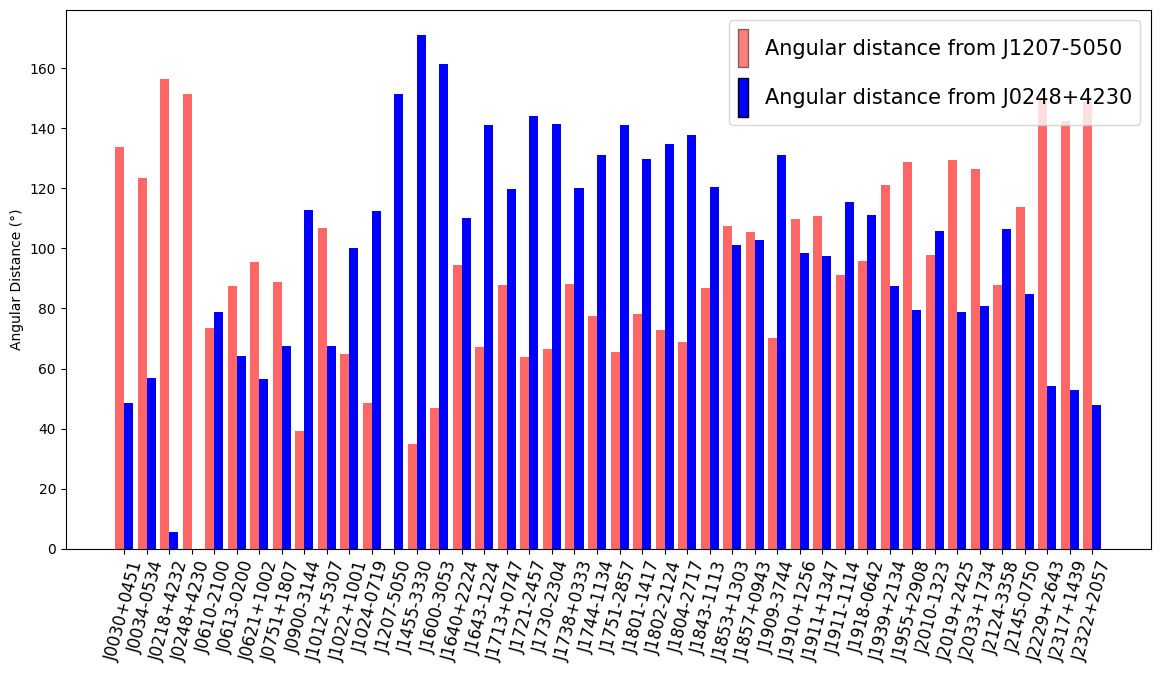

Processing Nanograv: 47 pulsars

Nanograv Angular Distance Statistics:
  From J1207-5050 → Mean: 105.09°, Median: 110.81°
  From J0248+4230 → Mean: 89.66°, Median: 91.61°


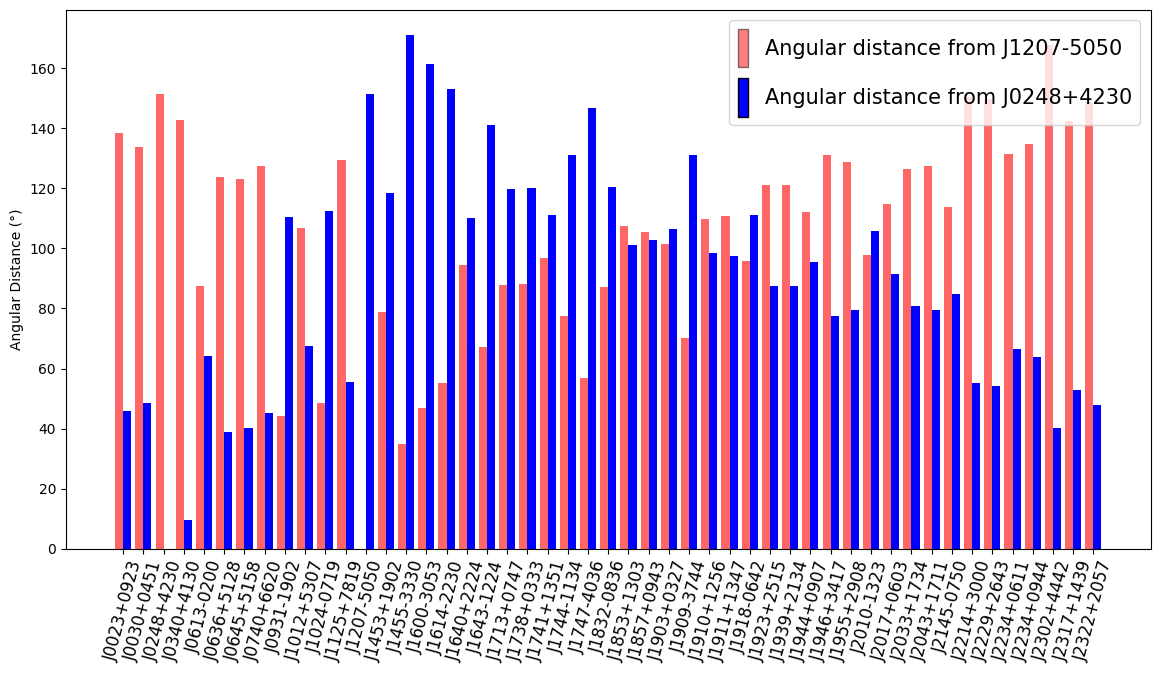

In [14]:
from psrqpy import QueryATNF
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Patch

# Define PTA pulsar groups
all_ptas = {"EPTA": EPTA, "Nanograv": NANOGrav}
all_TOAs = {"EPTA RMS": Epta_sigma_TOA, "Nanograv RMS": Nanograv_sigma_TOA}

highlight_pulsars = ["J1207-5050", "J0248+4230"]

def get_color(dist):
    """Assigns color based on angular distance significance"""
    if dist < 10:
        return "blue"  # Highly correlated
    elif dist < 30:
        return "orange"  # Moderate correlation
    else:
        return "blue"  # Independent signals

def query_and_plot(pta_name, pulsar_list, sigma_TOA):
    query_params = ["JNAME", "RAJD", "DECJD", "GL", "GB", "DM"]
    query = QueryATNF(params=query_params, psrs=pulsar_list + highlight_pulsars)
    pulsar_data = query.table
    
    valid_indices = ~np.isnan(pulsar_data["RAJD"]) & ~np.isnan(pulsar_data["DECJD"])
    pulsar_data = pulsar_data[valid_indices]
    
    ra_deg = np.array(pulsar_data["RAJD"], dtype=float)
    dec_deg = np.array(pulsar_data["DECJD"], dtype=float)
    
    gl = pulsar_data["GL"]
    gb = pulsar_data["GB"]
    dm_values = np.array(pulsar_data["DM"], dtype=float)
    pulsar_names_filtered = pulsar_data["JNAME"]
    
    coords = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")
    target_pulsars = {}
    
    for name in highlight_pulsars:
        idx = np.where(pulsar_names_filtered == name)[0]
        if len(idx) > 0:
            target_pulsars[name] = SkyCoord(l=gl[idx][0] * u.deg, b=gb[idx][0] * u.deg, frame="galactic")
    
    distance_J1207 = target_pulsars["J1207-5050"].separation(coords).deg
    distance_J0248 = target_pulsars["J0248+4230"].separation(coords).deg

    # 🔹 Calculate stats
    mean_J1207 = np.mean(distance_J1207)
    median_J1207 = np.median(distance_J1207)
    mean_J0248 = np.mean(distance_J0248)
    median_J0248 = np.median(distance_J0248)

    print(f"\n{pta_name} Angular Distance Statistics:")
    print(f"  From J1207-5050 → Mean: {mean_J1207:.2f}°, Median: {median_J1207:.2f}°")
    print(f"  From J0248+4230 → Mean: {mean_J0248:.2f}°, Median: {median_J0248:.2f}°")
    
    
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.4
    x_indexes = np.arange(len(pulsar_names_filtered))
    
    for i in range(len(pulsar_names_filtered)):
        #ax.bar(x_indexes[i] - bar_width/2, distance_J1207[i], width=bar_width, color=get_color(distance_J1207[i]))
        #ax.bar(x_indexes[i] + bar_width/2, distance_J0248[i], width=bar_width, color=get_color(distance_J0248[i]))
        ax.bar(x_indexes[i] - bar_width/2, distance_J1207[i], width=bar_width, color='red', alpha=0.6)
        ax.bar(x_indexes[i] + bar_width/2, distance_J0248[i], width=bar_width, color='blue')
    
    #ax.axhline(10, color="red", linestyle="--", label="Highly Correlated (<10°)")
    #ax.axhline(30, color="orange", linestyle="--", label="Moderate Correlation (10°–30°)")
    #ax.axhline(50, color="blue", linestyle="--", label="Independent (>30°)")
    
    
    ax.set_xticks(x_indexes)
    ax.set_xticklabels(pulsar_names_filtered, rotation=75, fontsize=12)
    ax.set_ylabel("Angular Distance (°)")
    #ax.set_title(f"Angular Distance of {pta_name} listed Pulsars from J1207-5050 & J0248+4230")

    # Add legend
    
# Custom legend handles with vertical bar style
    legend_elements = [
        Patch(facecolor='red',alpha= 0.5, label='Angular distance from J1207-5050', edgecolor='black'),
        Patch(facecolor='blue', label='Angular distance from J0248+4230', edgecolor='black')
    ]


    ax.legend(handles=legend_elements, handleheight=2.5, handlelength=0.5, loc='upper right', fontsize=15)
    #ax.grid()
    # Save plot
    filename = f"{pta_name}_angular_distance.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

for pta_name, pulsars in all_ptas.items():
    sigma_TOA = all_TOAs[f"{pta_name} RMS"]
    print(f"Processing {pta_name}: {len(pulsars)} pulsars")
    query_and_plot(pta_name, pulsars, sigma_TOA)

66
Extracted target pulsar coordinates:
  J1207-5050: (295.86114929229416, 11.421718425055934)
  J0248+4230: (144.87726960741128, -15.322393020003247)
5.163751183885024 0.19934659275292724 2.5285853659488393 -0.26742620748365403


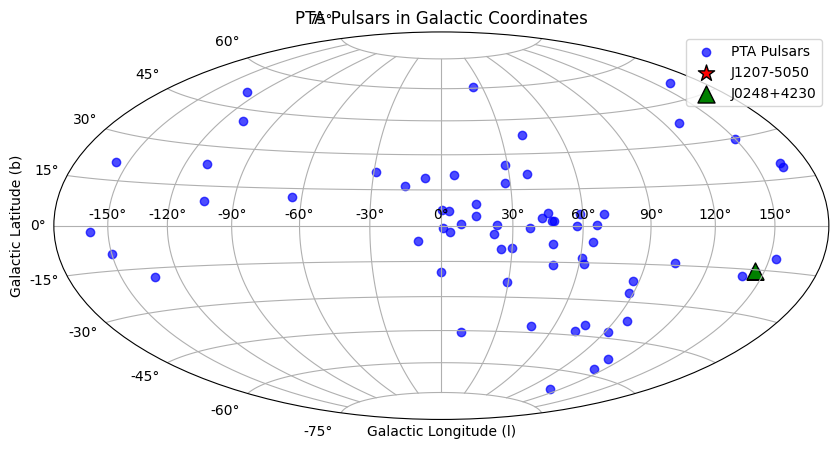

In [4]:


ra_deg = np.array(pulsar_data["RAJD"], dtype=float)
dec_deg = np.array(pulsar_data["DECJD"], dtype=float)
coords = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame="icrs")

gl = coords.galactic.l.deg  # Galactic Longitude (l)
gb = coords.galactic.b.deg  # Galactic Latitude (b)

# --- Extract Galactic Coordinates for J1207-5050 & J0248+4230 ---

pulsar_names = np.array(pulsar_data["JNAME"])
target_pulsars = {"J1207-5050": None, "J0248+4230": None}
print(len(pulsar_names))
for name in target_pulsars.keys():
    idx = np.where(pulsar_names == name)[0]
    if len(idx) > 0:
        target_pulsars[name] = (gl[idx][0], gb[idx][0])  # Store (l, b) values

# --- Debugging: Check Extracted Values ---
print("Extracted target pulsar coordinates:")
for name, coords in target_pulsars.items():
    print(f"  {name}: {coords}")

# Ensure both pulsars are found
if target_pulsars["J1207-5050"] is None or target_pulsars["J1207-5050"] is None:
    print("Error: One or both target pulsars not found in the dataset!")
    
# --- Convert to Radians for Plotting ---
gl_rad = np.radians(gl)
gb_rad = np.radians(gb)

# Shift longitude to center on l=0
gl_rad = np.where(gl_rad > np.pi, gl_rad - 2.0 * np.pi, gl_rad)

# Get target pulsar positions in radians
gl1, gb1 = target_pulsars["J1207-5050"]
gl2, gb2 = target_pulsars["J0248+4230"]
gl1_rad, gb1_rad = np.radians(gl1), np.radians(gb1)
gl2_rad, gb2_rad = np.radians(gl2), np.radians(gb2)
print(gl1_rad, gb1_rad, gl2_rad, gb2_rad)
# --- PLOT: Full-Sky Pulsar Distribution ---
plt.figure(figsize=(10, 7))
ax = plt.subplot(111, projection="hammer")

# Plot all PTA Pulsars
ax.scatter(gl_rad, gb_rad, c="blue", marker="o", label="PTA Pulsars", alpha=0.7)

# Highlight J1207-5050
ax.scatter(gl1_rad, gb1_rad, c="red", marker="*", s=150, label="J1207-5050", edgecolors="black")

# Highlight J0248+4230
ax.scatter(gl2_rad, gb2_rad, c="green", marker="^", s=150, label="J0248+4230", edgecolors="black")


ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("PTA Pulsars in Galactic Coordinates")

plt.legend()
plt.grid()
plt.show()



All ATNF MSPs:


  Count : 79
  Min   : 0.14 mJy
  Max   : 550.0 mJy
  Median: 6.8 mJy
  Count (<7.5 mJy): 41

EPTA MSPs:
  Count : 28
  Min   : 3.0 mJy
  Max   : 240.0 mJy
  Median: 11.0 mJy
  Count (<7.5 mJy): 8

NANOGrav MSPs:
  Count : 32
  Min   : 1.3 mJy
  Max   : 240.0 mJy
  Median: 7.05 mJy
  Count (<7.5 mJy): 17


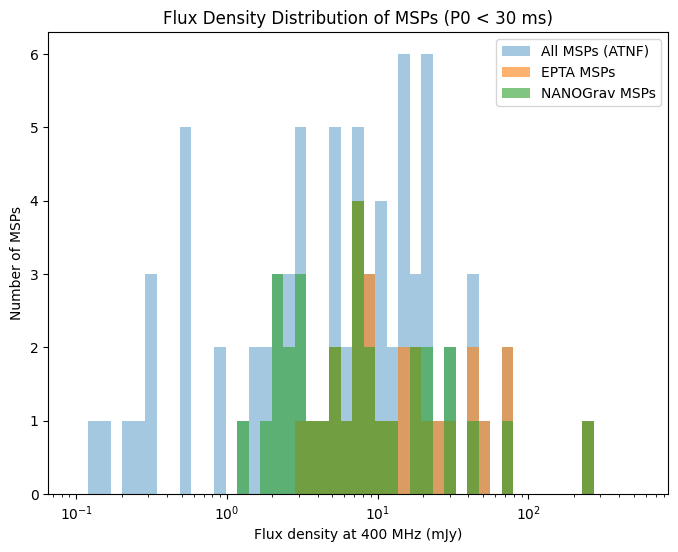

In [5]:
from psrqpy import QueryATNF
import numpy as np
import matplotlib.pyplot as plt

# Query ATNF for all pulsars with spin period and flux density
query_all = QueryATNF(params=["JNAME", "P0", "S400"])
all_data = query_all.table

# Filter only MSPs: P0 < 30 ms
msp_fluxes = []
for p0, s400 in zip(all_data["P0"], all_data["S400"]):
    try:
        if float(p0) < 0.03:  # P0 is in seconds, so 30 ms = 0.03 s
            val = float(s400)
            if np.isfinite(val):
                msp_fluxes.append(val)
    except Exception:
        continue
msp_fluxes = np.array(msp_fluxes)

# Extract fluxes for EPTA and NANOGrav lists
def get_fluxes(pulsar_list, pulsar_data):
    fluxes = []
    for pulsar in pulsar_list:
        if pulsar in pulsar_data["JNAME"]:
            idx = list(pulsar_data["JNAME"]).index(pulsar)
            S400 = pulsar_data["S400"][idx]
            try:
                val = float(S400)
                if np.isfinite(val):
                    fluxes.append(val)
            except Exception:
                continue
    return np.array(fluxes)

epta_fluxes = get_fluxes(EPTA, pulsar_data)
nanograv_fluxes = get_fluxes(NANOGrav, pulsar_data)

# Stats function with <4 mJy count
def describe_flux(fluxes, label):
    if len(fluxes) == 0:
        print(f"{label}: No valid fluxes")
        return
    print(f"\n{label} MSPs:")
    print(f"  Count : {len(fluxes)}")
    print(f"  Min   : {np.min(fluxes)} mJy")
    print(f"  Max   : {np.max(fluxes)} mJy")
    print(f"  Median: {np.median(fluxes)} mJy")
    print(f"  Count (<7.5 mJy): {np.sum(fluxes < 7.5)}")

# Print results
describe_flux(msp_fluxes, "All ATNF")
describe_flux(epta_fluxes, "EPTA")
describe_flux(nanograv_fluxes, "NANOGrav")

# Histogram
plt.figure(figsize=(8,6))
plt.hist(msp_fluxes, bins=np.logspace(np.log10(0.1), np.log10(max(msp_fluxes)), 50),
         alpha=0.4, label="All MSPs (ATNF)")
plt.hist(epta_fluxes, bins=np.logspace(np.log10(0.1), np.log10(max(msp_fluxes)), 50),
         alpha=0.6, label="EPTA MSPs")
plt.hist(nanograv_fluxes, bins=np.logspace(np.log10(0.1), np.log10(max(msp_fluxes)), 50),
         alpha=0.6, label="NANOGrav MSPs")

plt.xscale("log")
plt.xlabel("Flux density at 400 MHz (mJy)")
plt.ylabel("Number of MSPs")
plt.legend()
plt.title("Flux Density Distribution of MSPs (P0 < 30 ms)")
plt.show()


🔹 Final Conclusion
✅ J1207-5050 & J0248+4230 are Good PTA Candidates IF:
✔ Timing precision (σ_TOA) is improved below 1 µs.
✔ Spin stability (low Ṗ, stable P) is confirmed.
✔ DM variations are minimal over time.
✔ Ecliptic latitude (β) is within ~10° for good GW detection.
✔ Multi-frequency observations exist for ISM correction.
✔ They are well-distributed in sky coverage.
✔ Binary effects (if present) are well-modeled.

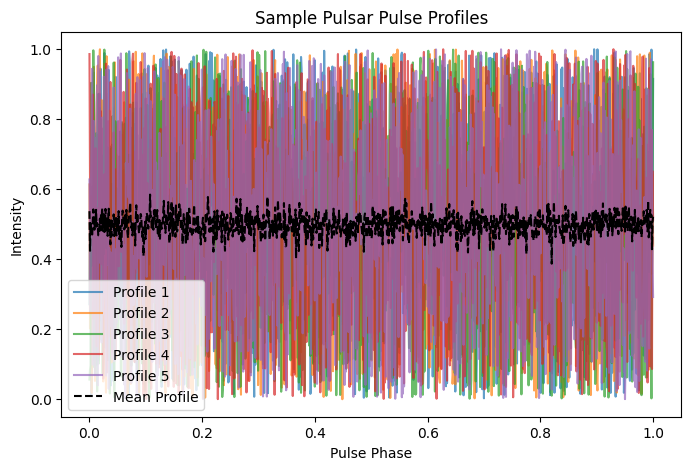

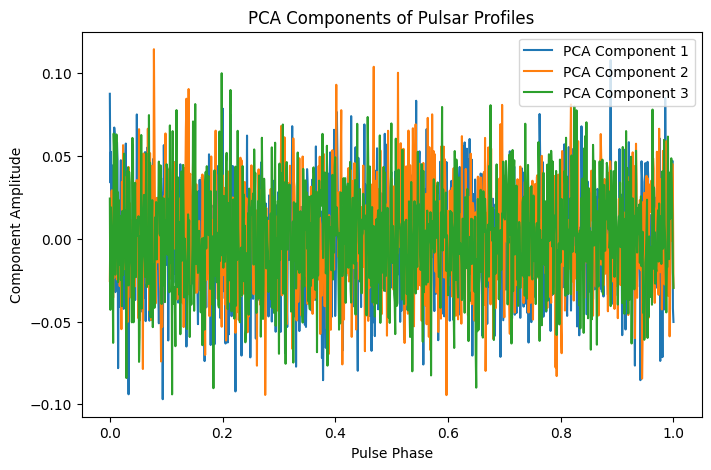

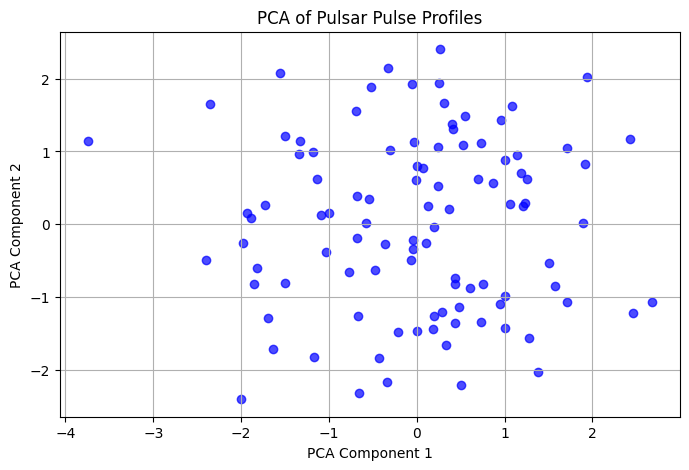

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Simulated pulse profile data (Replace with actual PFD file data)
n_profiles = 100  # 100 different observations (epochs)
n_bins = 1024  # 1024 phase bins per profile
pulse_profiles = np.random.rand(n_profiles, n_bins)  # Simulated profiles

# Compute mean pulse profile (average over all epochs)
mean_profile = np.mean(pulse_profiles, axis=0)

# Apply PCA (Reduce to 3 principal components)
pca = PCA(n_components=3)
pca_transformed = pca.fit_transform(pulse_profiles)
pca_components = pca.components_

# --- PLOT 1: Original Pulse Profiles (Random 5 Samples) ---
plt.figure(figsize=(8, 5))
for i in range(5):
    plt.plot(np.linspace(0, 1, n_bins), pulse_profiles[i], alpha=0.7, label=f"Profile {i+1}")
plt.plot(np.linspace(0, 1, n_bins), mean_profile, "k--", label="Mean Profile")
plt.xlabel("Pulse Phase")
plt.ylabel("Intensity")
plt.title("Sample Pulsar Pulse Profiles")
plt.legend()
plt.show()

# --- PLOT 2: PCA Components ---
plt.figure(figsize=(8, 5))
for i in range(3):  # Plot first 3 PCA components
    plt.plot(np.linspace(0, 1, n_bins), pca_components[i], label=f"PCA Component {i+1}")
plt.xlabel("Pulse Phase")
plt.ylabel("Component Amplitude")
plt.title("PCA Components of Pulsar Profiles")
plt.legend()
plt.show()

# --- PLOT 3: PCA Scatter Plot (First 2 Principal Components) ---
plt.figure(figsize=(8, 5))
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], c="blue", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA of Pulsar Pulse Profiles")
plt.grid()
plt.show()


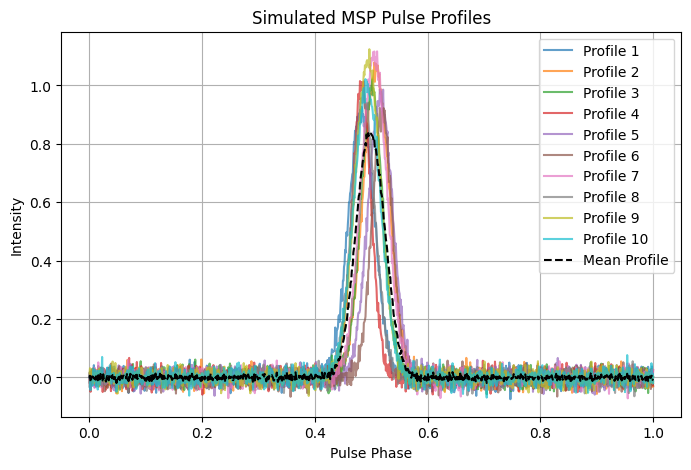

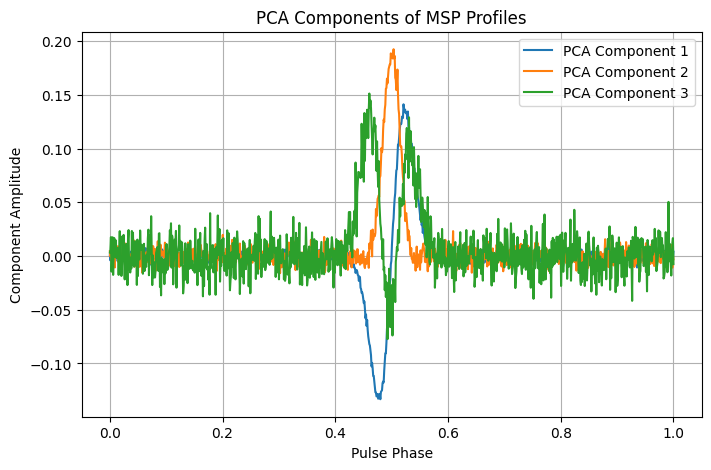

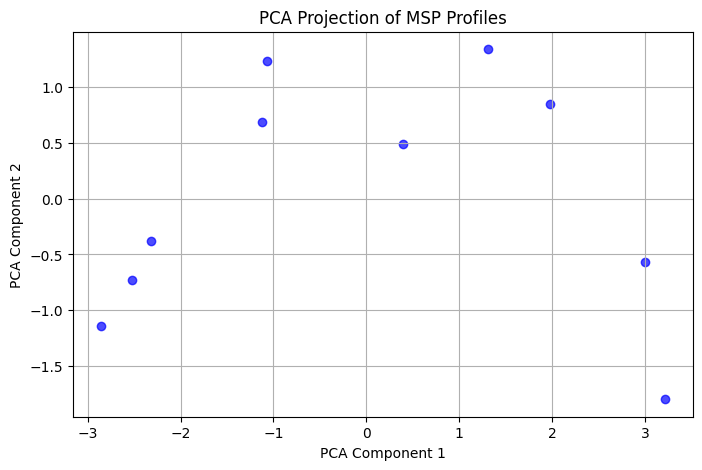

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Generate 10 MSP-like Pulse Profiles ---
n_profiles = 10  # Number of pulsars
n_bins = 1024  # Number of phase bins per profile

# Function to generate an MSP-like profile
def generate_msp_profile(phase_bins, center, width, amplitude, noise_level=0.02):
    profile = amplitude * np.exp(-((phase_bins - center) ** 2) / (2 * width ** 2))
    noise = np.random.normal(0, noise_level, size=len(phase_bins))  # Add small noise
    return profile + noise

# Create phase bins from 0 to 1
phase_bins = np.linspace(0, 1, n_bins)

# Generate 10 profiles with slight variations
profiles = np.array([
    generate_msp_profile(phase_bins, center=0.5 + np.random.uniform(-0.02, 0.02), 
                         width=0.02 + np.random.uniform(-0.005, 0.005), 
                         amplitude=1.0 + np.random.uniform(-0.1, 0.1))
    for _ in range(n_profiles)
])

# Compute mean profile
mean_profile = np.mean(profiles, axis=0)

# --- Apply PCA ---
pca = PCA(n_components=3)
pca_transformed = pca.fit_transform(profiles)
pca_components = pca.components_

# --- PLOT 1: Original MSP Profiles ---
plt.figure(figsize=(8, 5))
for i in range(n_profiles):
    plt.plot(phase_bins, profiles[i], alpha=0.7, label=f"Profile {i+1}")
plt.plot(phase_bins, mean_profile, "k--", label="Mean Profile")
plt.xlabel("Pulse Phase")
plt.ylabel("Intensity")
plt.title("Simulated MSP Pulse Profiles")
plt.legend()
plt.grid()
plt.show()

# --- PLOT 2: PCA Components ---
plt.figure(figsize=(8, 5))
for i in range(3):  # Plot first 3 PCA components
    plt.plot(phase_bins, pca_components[i], label=f"PCA Component {i+1}")
plt.xlabel("Pulse Phase")
plt.ylabel("Component Amplitude")
plt.title("PCA Components of MSP Profiles")
plt.legend()
plt.grid()
plt.show()

# --- PLOT 3: PCA Space Projection ---
plt.figure(figsize=(8, 5))
plt.scatter(pca_transformed[:, 0], pca_transformed[:, 1], c="blue", alpha=0.7)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of MSP Profiles")
plt.grid()
plt.show()


In [8]:
import psrqpy
from astropy.coordinates import SkyCoord
import astropy.units as u
import pandas as pd

# Step 1: Query ATNF pulsar catalogue (include P0 for period)
query = psrqpy.QueryATNF(params=['PSRJ', 'RAJ', 'DECJ', 'S400', 'P0'])
df = query.pandas  # Convert to pandas DataFrame

# Drop rows with missing RA/Dec, S400, or P0
df = df.dropna(subset=['RAJ', 'DECJ', 'S400', 'P0'])

# Step 2: Convert RA/Dec of pulsars to SkyCoord objects
coords = SkyCoord(df['RAJ'].values, df['DECJ'].values,
                  unit=(u.hourangle, u.deg), frame='icrs')

# Step 3: Define your target coordinate in sexagesimal format
target_ra = "02h16m00.00s"
target_dec = "-54d00m00.00s"
target_coord = SkyCoord(target_ra, target_dec, frame='icrs')

# Step 4: Compute angular separations
df['separation_deg'] = target_coord.separation(coords).deg

# Step 5: Convert period to milliseconds
df['Period_ms'] = df['P0'] * 1000.0

# Step 6: Apply flux density threshold (example: 10 mJy)
threshold = 10.0
df_filtered = df[df['S400'] > threshold].copy()

# Step 7: Add formatted RA/Dec in h:m:s / d:m:s
df_filtered['RA_hms'] = coords.ra.to_string(unit=u.hour, sep=':', precision=2)
df_filtered['Dec_dms'] = coords.dec.to_string(unit=u.deg, sep=':', precision=2, alwayssign=True)

# Step 8: Sort by separation and get top 10
df_sorted = df_filtered.sort_values(by='separation_deg').head(10)

# Print results
print("10 closest pulsars above threshold:")
print(df_sorted[['PSRJ', 'RA_hms', 'Dec_dms', 'S400', 'Period_ms', 'separation_deg']])


ValueError: Length of values (749) does not match length of index (341)